# Staypoint detection with GeoLife

A compact, reproducible comparison of staypoint detection with **fastmob** and GeoPandas-oriented **trackintel**. We use the same trajectory, thresholds, and output checks for both implementations.

In [1]:
%pip install -q fastmob trackintel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 6.6 MB/s eta 0:00:00


## 1. Load a real trajectory dataset

GeoLife contains timestamped GPS fixes for multiple users. The download is large, so the next cells keep the example focused on a deterministic slice.

In [2]:
!wget -O geolife.zip "https://download.microsoft.com/download/F/4/8/F4894AA5-FDBC-481E-9285-D5F8C4C4F039/Geolife%20Trajectories%201.3.zip"
!unzip -q geolife.zip -d geolife

--2026-09-09 12:14:27--  https://download.microsoft.com/download/F/4/8/F4894AA5-FDBC-481E-9285-D5F8C4C4F039/Geolife%20Trajectories%201.3.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.14.142.52, 2600:1407:3c00:e9b::317f, 2600:1407:3c00:ea3::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.14.142.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 313164406 (299M) [application/octet-stream]
Saving to: ‘geolife.zip’

geolife.zip         100%[===================>] 298.66M  67.3MB/s    in 4.3s    

2026-09-09 12:14:32 (69.7 MB/s) - ‘geolife.zip’ saved [313164406/313164406]



## 2. Import the tools

fastmob accepts ordinary dataframe columns. We normalize timestamps to UTC before running the detector.

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import trackintel as ti
import fastmob
import seaborn as sns

## 3. Set the detection contract

A staypoint is a stop lasting at least `minutes` inside a `radius_m` radius. `gap_minutes` separates observations when a device stops reporting.

In [4]:
# hyperparameters
minutes = 5
radius_m = 100
gap_minutes = 15

## 4. Prepare the trajectory

fastmob accepts ordinary dataframe columns. We normalize timestamps to UTC before running the detector.

In [11]:
tdf = fastmob.io.load_geolife_trajectories("/content/geolife/Geolife Trajectories 1.3").to_pandas()[:10_000_000]

tdf

,uid,lat,lng,datetime
0,000,39.984702,116.318417,2008-10-23 02:53:04
1,000,39.984683,116.318450,2008-10-23 02:53:10
2,000,39.984686,116.318417,2008-10-23 02:53:15
3,000,39.984688,116.318385,2008-10-23 02:53:20
4,000,39.984655,116.318263,2008-10-23 02:53:25
...,...,...,...,...
9999995,041,39.946090,116.207897,2009-06-05 09:42:59
9999996,041,39.945933,116.207798,2009-06-05 09:43:00
9999997,041,39.945780,116.207702,2009-06-05 09:43:01
9999998,041,39.945627,116.207605,2009-06-05 09:43:02


In [12]:
tdf["datetime"] = pd.to_datetime(tdf['datetime'], errors="coerce", utc=True)

In [13]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 4 columns):
 #   Column    Dtype              
---  ------    -----              
 0   uid       object             
 1   lat       float64            
 2   lng       float64            
 3   datetime  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), float64(2), object(1)
memory usage: 305.2+ MB


## 5. Benchmark fastmob

This timed cell measures the complete staypoint operation. Repeat it after changing the slice or thresholds; the first run may include warm-up costs.

In [ ]:
%%timeit

fastmob_result = fastmob.stay_locations(
    tdf,
    minutes_for_a_stop=minutes,
    spatial_radius_km=radius_m / 1000,
    no_data_for_minutes=gap_minutes,
    leaving_time=True,
)
del fastmob_result # Save system RAM

2.15 s ± 439 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 6. Build the GeoPandas-style baseline

trackintel works with a `Positionfixes` GeoDataFrame, so we create point geometry from the same latitude and longitude columns.

In [14]:
df = tdf.rename(columns={"uid": "user_id", "datetime": "tracked_at"})

gdf = gpd.GeoDataFrame(
  df,
  geometry=gpd.points_from_xy(df["lng"], df["lat"]),
  crs="EPSG:4326"
)

pfs = ti.Positionfixes(gdf)

del df, gdf

## 7. Benchmark the GeoPandas-style baseline

This uses trackintel's sliding-window detector with equivalent distance, time, gap, and trailing-stop settings.

In [ ]:
%%timeit

_, trackintel_result = pfs.generate_staypoints(
    method='sliding', dist_threshold=radius_m, time_threshold=minutes,
    gap_threshold=gap_minutes, include_last=True, n_jobs=-1,
)
del trackintel_result # Save System RAM

/usr/local/lib/python3.13/dist-packages/trackintel/preprocessing/positionfixes.py:112: UserWarning: 1912 duplicates were dropped from your positionfixes. Dropping duplicates is recommended but can be prevented using the 'exclude_duplicate_pfs' flag.
  warnings.warn(warn_str)
/usr/local/lib/python3.13/dist-packages/trackintel/preprocessing/positionfixes.py:112: UserWarning: 1912 duplicates were dropped from your positionfixes. Dropping duplicates is recommended but can be prevented using the 'exclude_duplicate_pfs' flag.
  warnings.warn(warn_str)
/usr/local/lib/python3.13/dist-packages/trackintel/preprocessing/positionfixes.py:112: UserWarning: 1912 duplicates were dropped from your positionfixes. Dropping duplicates is recommended but can be prevented using the 'exclude_duplicate_pfs' flag.
  warnings.warn(warn_str)
/usr/local/lib/python3.13/dist-packages/trackintel/preprocessing/positionfixes.py:112: UserWarning: 1912 duplicates were dropped from your positionfixes. Dropping duplicate

2min 50s ± 4.65 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 8. Compare the detected stops

The plot below shows one user's staypoints from both methods. Similar locations indicate comparable detection behavior; differences usually come from implementation details or edge handling.

In [8]:
fastmob_result = fastmob.stay_locations(
    tdf,
    minutes_for_a_stop=minutes,
    spatial_radius_km=radius_m / 1000,
    no_data_for_minutes=gap_minutes,
    leaving_time=True,
)

del tdf

In [15]:
trackintel_result = pfs.generate_staypoints(
    method='sliding', dist_threshold=radius_m, time_threshold=minutes,
    gap_threshold=gap_minutes, include_last=True, n_jobs=-1,
)

del pfs

/usr/local/lib/python3.13/dist-packages/trackintel/preprocessing/positionfixes.py:112: UserWarning: 1912 duplicates were dropped from your positionfixes. Dropping duplicates is recommended but can be prevented using the 'exclude_duplicate_pfs' flag.
  warnings.warn(warn_str)


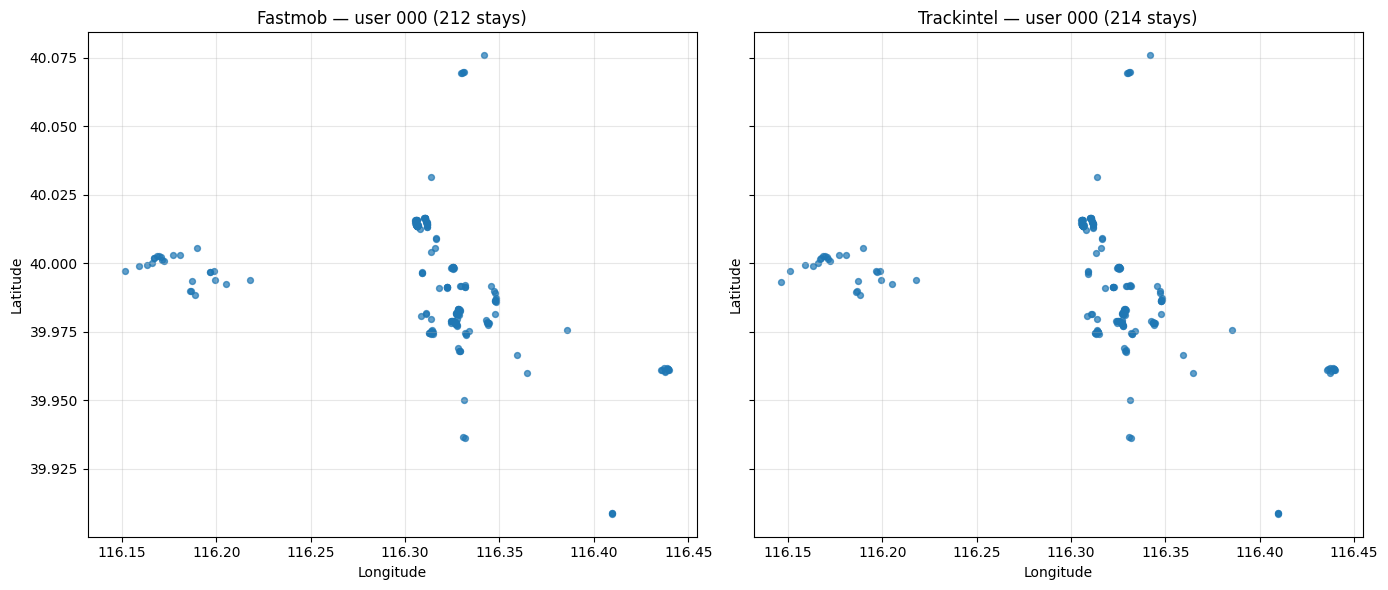

In [16]:
user_id = "001"

fm_full = fastmob_result
fm = fm_full[fm_full["uid"].astype(str).str.zfill(3) == user_id]

ti_full = trackintel_result[1]
ti_stays = ti_full[ti_full["user_id"].astype(str).str.zfill(3) == user_id]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(fm["lng"], fm["lat"], s=18, alpha=0.7)
axes[0].set_title(f"Fastmob — user 000 ({len(fm)} stays)")

axes[1].scatter(ti_stays.geometry.x, ti_stays.geometry.y, s=18, alpha=0.7)
axes[1].set_title(f"Trackintel — user 000 ({len(ti_stays)} stays)")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()